C:\Users\Sidqi\AppData\Local\Temp\ipykernel_9284\1281347045.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment_bert', palette='viridis')


Text(0, 0.5, 'Jumlah Review')

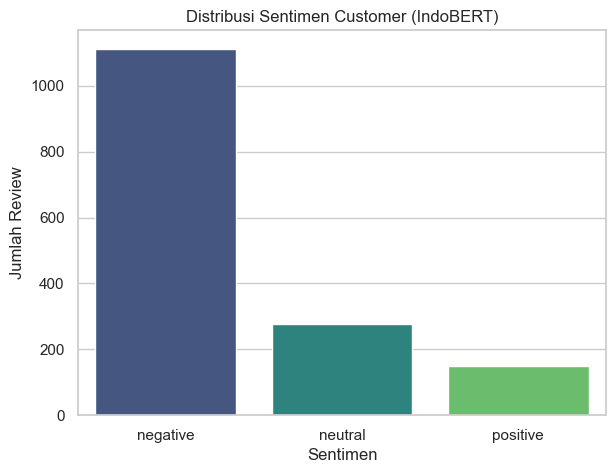

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

df = pd.read_csv('../data/jnt_final_labeled.csv')

sns.set(style="whitegrid")
plt.figure(figsize=(15, 5))

# Distribusi Sentimen IndoBERT
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='sentiment_bert', palette='viridis')
plt.title('Distribusi Sentimen Customer (IndoBERT)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')


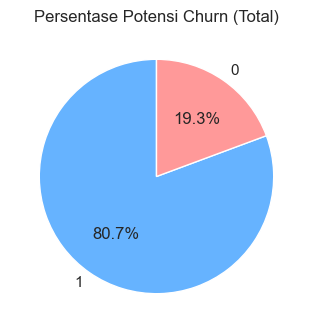

In [ ]:

# Perbandingan Churn vs Non-Churn
plt.subplot(1, 2, 2)
df['is_churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Persentase Potensi Churn (Total)')
plt.ylabel('')

plt.tight_layout()
plt.show()


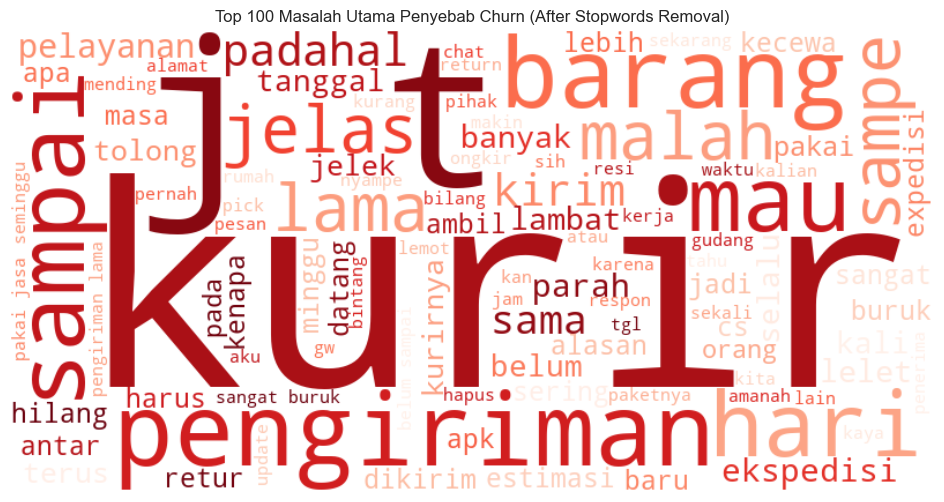

In [ ]:
# WordCloud
extra_stopwords = [
    'dan', 'saya', 'ini', 'sudah', 'nya', 'itu', 'di', 'ke', 'dari', 'paket', 
    'jnt', 'aplikasi', 'buat', 'kalau', 'tapi', 'ada', 'tidak', 'juga', 'untuk',
    'yang', 'saya', 'dengan', 'saya', 'bisa', 'kalo', 'cuma', 'masih', 'pas',
    'suruh', 'kasih', 'lagi', 'aja', 'ya', 'lah', 'kok', 'deh', 'saja', 'banget', 'j', 't',
]

# 2. Filter teks hanya kata-kata yang bukan stopwords
def remove_stopwords(text):
    words = text.split()
    cleaned_words = [w for w in words if w not in extra_stopwords]
    return " ".join(cleaned_words)

# Terapkan ke data Churn saja
churn_text_clean = df[df['is_churn'] == 1]['content_clean'].apply(remove_stopwords)
final_text = " ".join(churn_text_clean)

# 3. Generate WordCloud Baru
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='Reds',
    max_words=100 # Fokus ke 100 kata paling 'berisik'
).generate(final_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top 100 Masalah Utama Penyebab Churn (After Stopwords Removal)')
plt.show()